In [18]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# AAAI PUBLICATION STYLE CONFIGURATION
# ---------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.grid": True,
    "grid.color": "#eaeaea",     # Soft subtle grid lines
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "axes.spines.top": False,    # Clean Tufte-style framing
    "axes.spines.right": False
})

def compute_rolling_avg(data, window=10):
    if len(data) == 0: return data
    window = min(window, len(data))
    res = np.zeros_like(data)
    for i in range(len(data)):
        start = max(0, i - window + 1)
        res[i] = np.mean(data[start:i+1])
    return res

def run_analysis_pipeline(experiment_name, SEEDS, NUM_EPISODES, ALGORITHMS, COLORS, WINDOW_SIZE):
    # --- DATA LOADING ---
    results_raw = {
        alg_name: {"episode_rewards": [], "success_flags": [], "collision_flags": [], "episode_lengths": []} 
        for alg_name in ALGORITHMS
    }

    for alg_name in ALGORITHMS:
        for seed in SEEDS:
            history_path = f"experiments_results/{experiment_name}/histories/{alg_name}_S{seed}.json"
            if not os.path.exists(history_path):
                continue
                
            try:
                with open(history_path, "r", encoding="utf-8") as f:
                    history = json.load(f)
                
                results_raw[alg_name]["episode_rewards"].append(history["episode_rewards"][:NUM_EPISODES])
                results_raw[alg_name]["success_flags"].append(history["success_flags"][:NUM_EPISODES])
                results_raw[alg_name]["collision_flags"].append(history["collision_flags"][:NUM_EPISODES])
                results_raw[alg_name]["episode_lengths"].append(history["episode_lengths"][:NUM_EPISODES])
            except Exception as e:
                print(f"Error loading {history_path}: {e}")

    # --- DATA PROCESSING & SPECIFIC ALGORITHM SWAP ---
    results_processed = {}
    for alg_name in ALGORITHMS:
        source_name = alg_name
        
        results_processed[alg_name] = {}
        for metric_name in ["episode_rewards", "success_flags", "collision_flags", "episode_lengths"]:
            raw_runs = results_raw[source_name][metric_name]
            if not raw_runs:
                continue
                
            data_matrix = np.array(raw_runs, dtype=np.float32)
            if metric_name in ["success_flags", "collision_flags"]:
                data_matrix = data_matrix * 100.0
                
            results_processed[alg_name][metric_name] = {
                "mean": np.mean(data_matrix, axis=0),
                "std": np.std(data_matrix, axis=0)
            }

    # --- PLOTTING ---
    fig, axs = plt.subplots(2, 2, figsize=(8, 5.5))

    metrics = [
        ("success_flags", "Success Rate (%)", axs[0, 0]),
        ("collision_flags", "Collision Rate (%)", axs[0, 1]),
        ("episode_rewards", "Average Reward", axs[1, 0]),
        ("episode_lengths", "Avg Travel Time (Steps)", axs[1, 1])
    ]

    episodes_x = np.arange(1, NUM_EPISODES + 1)
    legend_lines = []
    legend_labels = []

    for metric_key, ylabel, ax in metrics:
        ax.set_ylabel(ylabel, fontweight="bold")
        
        if ax in axs[1, :]:
            ax.set_xlabel("Episode")
        
        for alg_name, color in COLORS.items():
            if alg_name not in results_processed:
                continue
            
            mean_raw = results_processed[alg_name][metric_key]["mean"]
            std_raw = results_processed[alg_name][metric_key]["std"]
            
            mean_smooth = compute_rolling_avg(mean_raw, WINDOW_SIZE)
            std_smooth = compute_rolling_avg(std_raw, WINDOW_SIZE)
            
            # --- VISUAL IMPROVEMENTS: Z-ORDER & ALPHA STRATEGY ---
            if alg_name == "MAPS":
                z_order = 5
                line_width = 2.0
                line_alpha = 1.0
                shade_alpha = 0.15
            else:
                z_order = 2
                line_width = 1.3
                line_alpha = 0.8  
                shade_alpha = 0.05
                
            line, = ax.plot(
                episodes_x, mean_smooth, 
                label=alg_name, color=color, 
                linewidth=line_width, 
                alpha=line_alpha,
                zorder=z_order
            )
            
            ax.fill_between(
                episodes_x,
                mean_smooth - std_smooth,
                mean_smooth + std_smooth,
                color=color,
                alpha=shade_alpha,
                edgecolor="none",
                zorder=z_order - 1
            )
            
            if metric_key == "success_flags":
                legend_lines.append(line)
                legend_labels.append(alg_name)

    fig.legend(legend_lines, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=5, frameon=False)

    plt.tight_layout()
    os.makedirs("plots", exist_ok=True)
    plt.savefig("plots/algorithm_comparison.pdf", dpi=300, bbox_inches="tight")
    plt.show()

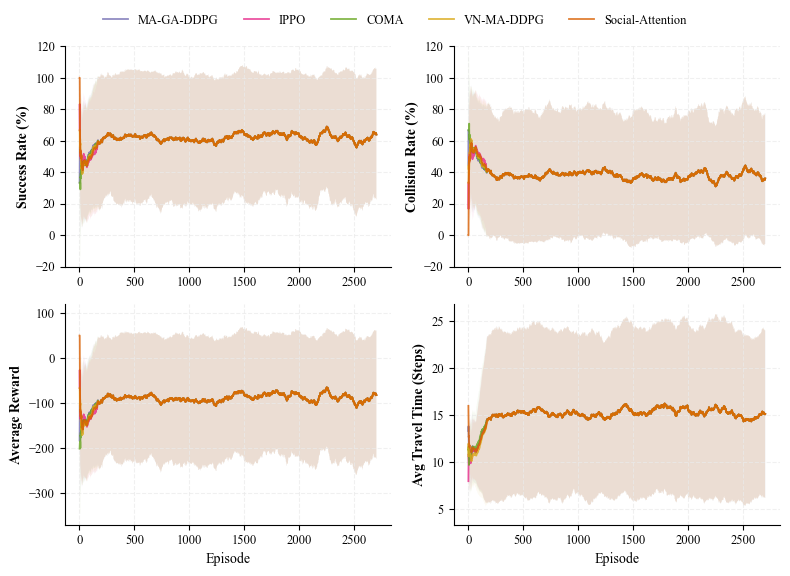

In [37]:
# --- EXPERIMENT PATH & PARAMETERS ---
# experiment_name = "intersection_3_seeds_2700_episodes"
# experiment_name = "roundabout_3_seeds_2700_episodes"
experiment_name = "rerun_all_2700"
SEEDS = [42,100,2026]
# SEEDS = [42]
NUM_EPISODES = 2700
# NUM_EPISODES = 1763
WINDOW_SIZE = 100

# --- ALGORITHM DICTIONARY MAPS ---
ALGORITHMS = {
    # "MAPS": "experiment",
    "MA-GA-DDPG": "ma_ga_ddpg",
    "IPPO": "ippo",
    "COMA": "coma",
    "VN-MA-DDPG": "vn_ma_ddpg",
    "Social-Attention": "social_attention",
}

# --- PALETTE CONFIGURATIONS ---
COLORS = {
    "MAPS": "#008080",              
    "MA-GA-DDPG": "#7570b3",
    "IPPO": "#e7298a",              
    "COMA": "#66a61e",
    "VN-MA-DDPG": "#d9a714",
    "Social-Attention": "#d95f02",  
}

# --- EXECUTE ANALYSIS ---
run_analysis_pipeline(
    experiment_name=experiment_name,
    SEEDS=SEEDS,
    NUM_EPISODES=NUM_EPISODES,
    ALGORITHMS=ALGORITHMS,
    COLORS=COLORS,
    WINDOW_SIZE=WINDOW_SIZE
)

In [36]:
import json
import re
import os
import glob

def recover_history_from_log(log_filepath, output_json_path):
    if not os.path.exists(log_filepath):
        print(f"Error: Log file not found at {log_filepath}")
        return

    print(f"Scanning {log_filepath} for episode results...")
    
    with open(log_filepath, 'r', encoding='utf-8') as f:
        log_content = f.read()
    
    episode_rewards = []
    actor_losses = []
    critic_losses = []
    collision_flags = []
    success_flags = []  
    episode_lengths = []
    
    # Split the log into chunks based on the episode start lines
    episode_blocks = re.split(r'This is the\s+\d+\s+Out of\s+\d+\s+episodes', log_content)
    
    # Skip the first block (index 0) as it's just pre-training setup
    for block in episode_blocks[1:]:
        
        # 1. Episode Rewards: Grab the final reward logged
        reward_matches = re.findall(r"Reward:\s*([\-\d\.]+)", block)
        if reward_matches:
            episode_rewards.append(float(reward_matches[-1]))
        else:
            episode_rewards.append(0.0)
            
        # 2. Collision & Success Flags
        if "crashed!" in block:
            collision_flags.append(1)
            success_flags.append(0)
        else:
            collision_flags.append(0)
            if "Arrived" in block or (reward_matches and float(reward_matches[-1]) > 0):
                success_flags.append(1)
            else:
                success_flags.append(0)
            
        # 3. Episode Lengths (Steps)
        steps = len(re.findall(r"Min Reward:", block))
        if steps == 0:
            step_match = re.search(r"trained on (\d+) steps", block)
            if step_match:
                steps = int(step_match.group(1))
        episode_lengths.append(steps)
        
        # 4. Losses
        actor_match = re.findall(r"actor_loss[\s:]*([\-\d\.]+)", block, re.IGNORECASE)
        if actor_match:
            actor_losses.append(float(actor_match[-1]))
        else:
            actor_losses.append(0.0) 
            
        critic_match = re.findall(r"critic_loss[\s:]*([\-\d\.]+)", block, re.IGNORECASE)
        if critic_match:
            critic_losses.append(float(critic_match[-1]))
        else:
            critic_losses.append(0.0) 

    history_data = {
        "episode_rewards": episode_rewards,
        "actor_losses": actor_losses,
        "critic_losses": critic_losses,
        "collision_flags": collision_flags,
        "success_flags": success_flags,  
        "episode_lengths": episode_lengths
    }

    # Ensure the output directory exists
    output_dir = os.path.dirname(output_json_path)
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    # Save to JSON
    with open(output_json_path, 'w', encoding='utf-8') as f:
        json.dump(history_data, f, indent=4)
        
    print(f"Successfully recovered {len(episode_rewards)} episodes from {os.path.basename(log_filepath)}!")


def batch_process_logs(experiment_dir):
    """Finds all .log files in the process_logs folder and converts them to JSON."""
    logs_dir = os.path.join(experiment_dir, "process_logs")
    histories_dir = os.path.join(experiment_dir, "histories")
    
    # Find all .log files in the process_logs folder
    log_files = glob.glob(os.path.join(logs_dir, "*.log"))
    
    if not log_files:
        print(f"No log files found in {logs_dir}")
        return

    print(f"Found {len(log_files)} log file(s) to process.\n---")

    for log_path in log_files:
        # Get the filename without extension (e.g., "VN-MA-DDPG_S42")
        filename_without_ext = os.path.splitext(os.path.basename(log_path))[0]
        
        # Define output JSON path under the histories directory
        output_json_path = os.path.join(histories_dir, f"{filename_without_ext}.json")
        
        # Process the log file
        recover_history_from_log(log_path, output_json_path)
        
    print("\nAll files processed successfully!")


# --- CONFIGURATION ---
EXPERIMENT_NAME_DIR = "rerun_all_2700"
BASE_DIR = f"experiments_results/{EXPERIMENT_NAME_DIR}"

# Run the batch processor
batch_process_logs(BASE_DIR)

Found 15 log file(s) to process.
---
Scanning experiments_results/rerun_all_2700\process_logs\COMA_S100.log for episode results...
Successfully recovered 2700 episodes from COMA_S100.log!
Scanning experiments_results/rerun_all_2700\process_logs\COMA_S2026.log for episode results...
Successfully recovered 2700 episodes from COMA_S2026.log!
Scanning experiments_results/rerun_all_2700\process_logs\COMA_S42.log for episode results...
Successfully recovered 2700 episodes from COMA_S42.log!
Scanning experiments_results/rerun_all_2700\process_logs\IPPO_S100.log for episode results...
Successfully recovered 2700 episodes from IPPO_S100.log!
Scanning experiments_results/rerun_all_2700\process_logs\IPPO_S2026.log for episode results...
Successfully recovered 2700 episodes from IPPO_S2026.log!
Scanning experiments_results/rerun_all_2700\process_logs\IPPO_S42.log for episode results...
Successfully recovered 2700 episodes from IPPO_S42.log!
Scanning experiments_results/rerun_all_2700\process_logs\